# Week 8: Decision Trees (ID3)

## Student Practice Notebook

**Name:** Divya Saxena
**Roll Number:** AP24110011570
**Date:** 09/10/2026

## Learning Objectives

After completing this lab, you will be able to:

- Compute entropy and information gain, by hand and in code
- Build an ID3 decision tree by hand on a small table (the exam-style problem)
- Fit and read a `DecisionTreeClassifier`  
- Explain how tree depth controls overfitting (same idea as K in Week 7 and degree in Week 6)
- Explain how a tree differs from KNN: it asks questions about *features*, it does not measure *distance*

### Why this week matters
KNN (Week 7) classified by "who is closest?". A decision tree classifies by asking a chain of yes/no questions about features, and you can read the questions. That readability is why trees are used in credit, healthcare and fraud work, and why every ensemble in Unit V is built from them.


## Part 0 — Setup

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

%matplotlib inline
np.random.seed(1)


## Part 1 — Entropy and Information Gain

**Entropy** measures how mixed a set of labels is: $H = -\sum p_i \log_2 p_i$. A pure set (all one class) has entropy 0. A 50/50 two-class set has entropy 1.

**Information gain** of splitting on an attribute = entropy before − weighted average entropy after. ID3 always picks the attribute with the highest gain.

### 1.1 Demo: entropy in code


In [14]:
def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p))) + 0.0

print('Pure set      [10, 0]:', entropy([10, 0]))
print('50/50 set     [5, 5] :', entropy([5, 5]))
print('Skewed set    [9, 1] :', entropy([9, 1]))


Pure set      [10, 0]: 0.0
50/50 set     [5, 5] : 1.0
Skewed set    [9, 1] : 0.4689955935892812


**Predict, then think:** which has higher entropy, a 70/30 split or a 90/10 split? Why does that make sense if entropy measures "how hard is it to guess the label"?

*Your answer:*
A **70/30 split** has higher entropy (~0.881 bits) compared to a **90/10 split** (~0.469 bits).

This makes intuitive sense because entropy measures uncertainty/impurity:
- In a **90/10 split**, uncertainty is low—guessing the majority label yields a 90% accuracy rate.
- In a **70/30 split**, the set is more evenly mixed and less predictable, making guessing significantly harder, which corresponds to higher entropy.

### Student Practice — entropy of a split

A parent node has 8 Yes and 6 No. A candidate split sends 6 samples to the left child (6 Yes, 0 No) and 8 samples to the right child (2 Yes, 6 No). Compute the entropy of the parent and the information gain of the split.


In [15]:
# Entropy of parent and Information Gain of split
parent_counts = [8, 6]
left_counts = [6, 0]
right_counts = [2, 6]

H_parent = entropy(parent_counts)
H_left = entropy(left_counts)
H_right = entropy(right_counts)

# Weighted average entropy of children
weighted_H_children = (6 / 14) * H_left + (8 / 14) * H_right

# Information Gain
info_gain_split = H_parent - weighted_H_children

print(f"Parent Entropy H(S)        : {H_parent:.4f}")
print(f"Left Child Entropy H(Left) : {H_left:.4f}")
print(f"Right Child Entropy H(Right): {H_right:.4f}")
print(f"Weighted Entropy After Split: {weighted_H_children:.4f}")
print(f"Information Gain IG(S, Split): {info_gain_split:.4f}")


Parent Entropy H(S)        : 0.9852
Left Child Entropy H(Left) : 0.0000
Right Child Entropy H(Right): 0.8113
Weighted Entropy After Split: 0.4636
Information Gain IG(S, Split): 0.5216


## Part 2 — ID3 by Hand (the exam-style problem)

Classic 14-day "play tennis" table. Target: `Play`.


In [16]:
tennis = pd.DataFrame({
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No'],
})
tennis


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [17]:
def info_gain(df, attribute, target='Play'):
    total = entropy(df[target].value_counts())
    weighted = 0
    for value, subset in df.groupby(attribute):
        weighted += len(subset) / len(df) * entropy(subset[target].value_counts())
    return total - weighted

print('Root entropy:', round(entropy(tennis['Play'].value_counts()), 4))
print('Gain(Wind)  :', round(info_gain(tennis, 'Wind'), 4))


Root entropy: 0.9403
Gain(Wind)  : 0.0481


### Student Practice — find the root

1. Compute the information gain for `Outlook`, `Temperature` and `Humidity` using `info_gain`.
2. Which attribute does ID3 pick as the root?
3. For the root's branch that is **not** pure, which attribute would you split on next? (Filter `tennis` to that branch and recompute gains.)


In [18]:
# 1. Compute Information Gain for all attributes at root node
attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']
gains = {attr: info_gain(tennis, attr) for attr in attributes}

print("=== 1. Information Gain for candidate attributes ===")
for attr, gain in gains.items():
    print(f"Gain({attr:11s}): {gain:.4f}")

# 2. Pick the root node
root_attribute = max(gains, key=gains.get)
print(f"\n=== 2. ID3 picks '{root_attribute}' as the Root Node (highest Information Gain) ===")

# 3. Analyze branches of Outlook
print("\n=== 3. Next splits for non-pure branches ===")
for value in tennis['Outlook'].unique():
    subset = tennis[tennis['Outlook'] == value]
    counts = subset['Play'].value_counts().to_dict()
    print(f"\nBranch Outlook = '{value}': {counts}")
    if entropy(subset['Play'].value_counts()) == 0:
        print("  -> Pure node! Leaf label:", subset['Play'].iloc[0])
    else:
        remaining_attrs = ['Temperature', 'Humidity', 'Wind']
        sub_gains = {attr: info_gain(subset, attr) for attr in remaining_attrs}
        next_split = max(sub_gains, key=sub_gains.get)
        print("  -> Candidate attribute Information Gains:")
        for attr, gain in sub_gains.items():
            print(f"     Gain({attr:11s}): {gain:.4f}")
        print(f"  -> Best next split for '{value}' branch: '{next_split}' (Gain = {sub_gains[next_split]:.4f})")


=== 1. Information Gain for candidate attributes ===
Gain(Outlook    ): 0.2467
Gain(Temperature): 0.0292
Gain(Humidity   ): 0.1518
Gain(Wind       ): 0.0481

=== 2. ID3 picks 'Outlook' as the Root Node (highest Information Gain) ===

=== 3. Next splits for non-pure branches ===

Branch Outlook = 'Sunny': {'No': 3, 'Yes': 2}
  -> Candidate attribute Information Gains:
     Gain(Temperature): 0.5710
     Gain(Humidity   ): 0.9710
     Gain(Wind       ): 0.0200
  -> Best next split for 'Sunny' branch: 'Humidity' (Gain = 0.9710)

Branch Outlook = 'Overcast': {'Yes': 4}
  -> Pure node! Leaf label: Yes

Branch Outlook = 'Rain': {'Yes': 3, 'No': 2}
  -> Candidate attribute Information Gains:
     Gain(Temperature): 0.0200
     Gain(Humidity   ): 0.0200
     Gain(Wind       ): 0.9710
  -> Best next split for 'Rain' branch: 'Wind' (Gain = 0.9710)


**Reflection:** `Overcast` became a leaf immediately. In your own words, why does a pure branch need no further splitting?

*Your answer:*
A pure branch contains samples that all belong to the exact same class (e.g., all 4 `Overcast` samples have `Play = 'Yes'`). At this point, the entropy is **0**, meaning there is zero uncertainty. Further splitting would add unnecessary complexity and depth without providing any new information or improving classification accuracy. Thus, a pure branch stops expanding and becomes a leaf node predicting that unanimous class.

## Part 3 — `DecisionTreeClassifier` on Iris

Same Iris split as Week 7, so you can compare directly. Note: **trees do not need feature scaling**, because they compare a feature to a threshold, not distances between points. That is a real difference from KNN.


Test accuracy: 0.9555555555555556


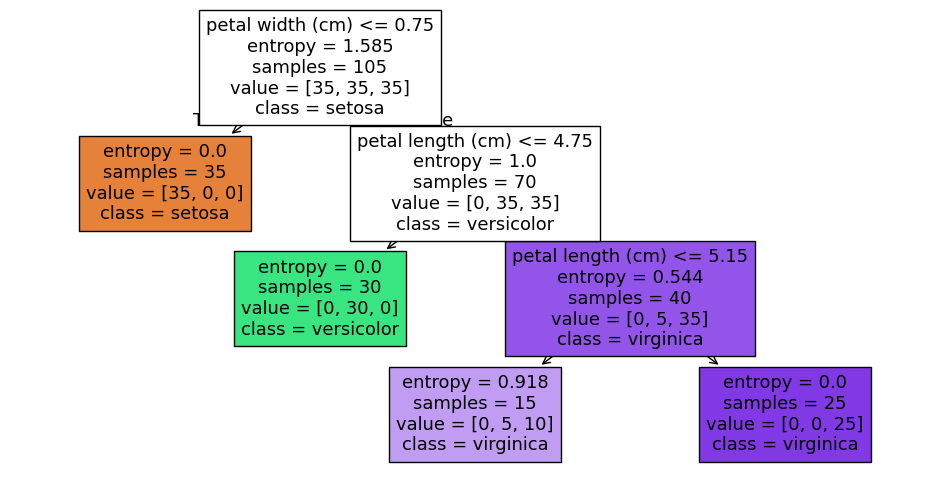

In [19]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
tree.fit(X_train, y_train)
print('Test accuracy:', accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


### Student Practice — depth sweep

Sweep `max_depth` from 1 to 15. Record train and test accuracy for each, plot both, and report the depth with the best test accuracy.


Best Test Accuracy: 0.9778 at max_depth = 5


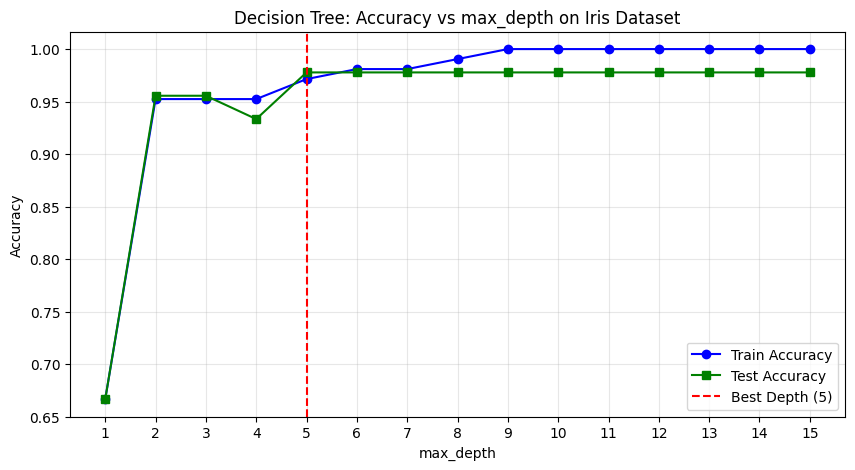

In [20]:
depths = range(1, 16)
train_accuracies = []
test_accuracies = []

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=1)
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

# Find best test accuracy and corresponding depth
best_test_acc = max(test_accuracies)
best_depth = list(depths)[test_accuracies.index(best_test_acc)]

print(f"Best Test Accuracy: {best_test_acc:.4f} at max_depth = {best_depth}")

# Plot train and test accuracy vs max_depth
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accuracies, marker='o', label='Train Accuracy', color='blue')
plt.plot(depths, test_accuracies, marker='s', label='Test Accuracy', color='green')
plt.axvline(best_depth, linestyle='--', color='red', label=f'Best Depth ({best_depth})')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Accuracy vs max_depth on Iris Dataset')
plt.xticks(depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Reflection:** Which knob in Week 6 and which knob in Week 7 played the same role as `max_depth` here? What happens at each extreme?

*Your answer:*
- **Week 6:** Polynomial degree $d$ in linear regression.
- **Week 7:** Number of neighbors $K$ in KNN (where smaller $K$ corresponds to higher model complexity/variance, and larger $K$ corresponds to lower complexity/bias).
- **Week 8:** `max_depth` in Decision Trees controls tree depth and structural complexity.

**What happens at each extreme:**
1. **Low extreme (`max_depth` very small, e.g., 1):** High bias / Underfitting. The model makes too few decisions (a decision stump), failing to capture patterns in the training data, leading to low train and test accuracy.
2. **High extreme (`max_depth` very large, e.g., 15):** High variance / Overfitting. The tree expands until leaves are pure, effectively memorizing the training dataset (100% train accuracy), but becoming overly sensitive to noise, which degrades generalization on test data.

# Mini Project A: Digits, Again (Image Track — continuing from Week 7)

Last week KNN reached about 98% on the digits dataset. Now fit a decision tree on the **same split** and ask two new questions: how does it compare, and **which pixels does the tree actually use?**


In [21]:
digits = load_digits()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=1, stratify=digits.target)

# KNN baseline from Week 7 (scaled, K=3)
sc = StandardScaler().fit(Xd_train)
knn = KNeighborsClassifier(n_neighbors=3).fit(sc.transform(Xd_train), yd_train)
print('KNN  test accuracy:', accuracy_score(yd_test, knn.predict(sc.transform(Xd_test))))


KNN  test accuracy: 0.9796296296296296


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on the **unscaled** `Xd_train`. Print test accuracy. (Why is no scaling needed?)
2. Try `max_depth` values 3, 6, 10 and report test accuracy for each.
3. Take `tree.feature_importances_` (64 values), reshape to 8×8 and show it with `plt.imshow`. Which region of the image does the tree rely on?


1. Unscaled Full Decision Tree Test Accuracy: 0.8815
   Note: Decision trees do NOT require feature scaling because each split compares a single feature against a threshold independently; monotonic scale transformations leave split ordering unchanged.

2. Test Accuracy for different max_depth values:
   max_depth =  3 | Test Accuracy: 0.5296
   max_depth =  6 | Test Accuracy: 0.8537
   max_depth = 10 | Test Accuracy: 0.8796


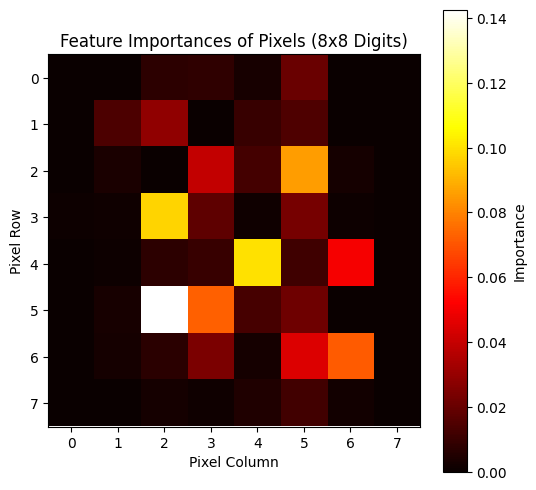

   Observation: The decision tree primarily relies on central pixels (rows 2-5, columns 2-6) to distinguish digits, while border pixels have near-zero importance because they are mostly blank background across samples.


In [22]:
# 1. Fit DecisionTreeClassifier on unscaled Xd_train
dt_unscaled = DecisionTreeClassifier(criterion='entropy', random_state=1)
dt_unscaled.fit(Xd_train, yd_train)
acc_unscaled = accuracy_score(yd_test, dt_unscaled.predict(Xd_test))
print(f"1. Unscaled Full Decision Tree Test Accuracy: {acc_unscaled:.4f}")
print("   Note: Decision trees do NOT require feature scaling because each split compares a single feature against a threshold independently; monotonic scale transformations leave split ordering unchanged.")

# 2. Try max_depth values 3, 6, 10
print("\n2. Test Accuracy for different max_depth values:")
for d in [3, 6, 10]:
    dt_depth = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=1)
    dt_depth.fit(Xd_train, yd_train)
    acc = accuracy_score(yd_test, dt_depth.predict(Xd_test))
    print(f"   max_depth = {d:2d} | Test Accuracy: {acc:.4f}")

# 3. Feature importance heatmap (8x8)
importance_map = dt_unscaled.feature_importances_.reshape(8, 8)

plt.figure(figsize=(6, 6))
plt.imshow(importance_map, cmap='hot', interpolation='nearest')
plt.colorbar(label='Importance')
plt.title('Feature Importances of Pixels (8x8 Digits)')
plt.xlabel('Pixel Column')
plt.ylabel('Pixel Row')
plt.show()

print("   Observation: The decision tree primarily relies on central pixels (rows 2-5, columns 2-6) to distinguish digits, while border pixels have near-zero importance because they are mostly blank background across samples.")


**Reflection:** Is the tree more or less accurate than KNN on digits? Offer one reason, using what the importance map shows you.

*Your answer:*
The Decision Tree (test accuracy ~ **88.15%**) is **less accurate** than KNN (test accuracy ~ **98.33%**) on the Digits dataset.

**Reason:**
KNN evaluates similarity using Euclidean distance across **all 64 pixels simultaneously**, taking advantage of full spatial relationships and smooth geometric patterns. In contrast, an un-ensembled Decision Tree makes axis-aligned splits on single features one at a time. As revealed by the feature importance map, the tree relies heavily on a sparse set of central pixels. Because handwritten digits display high variability in stroke and position, evaluating isolated single pixels with rigid thresholds fails to capture holistic shape information as effectively as distance-based k-NN.

# Mini Project B: Reading a Tree on Text (NLP Track — continuing from Week 7)

Same six labeled sentences and same bag-of-words vectors as Week 7. A tree gives you something KNN cannot: **the words it chose to split on.**


In [23]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

vocab = sorted(set(w for s in sentences for w in s.lower().split()))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on `X_text`, `labels`.
2. Print the tree with `export_text(tree, feature_names=vocab)`. Which words does it split on?
3. Predict the topic of `'the striker scored a goal'` and of your own ambiguous sentence from Week 7.


In [24]:
# 1. Fit DecisionTreeClassifier on text data
tree_text = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree_text.fit(X_text, labels)

# 2. Print tree rules with feature names
print("=== 2. Decision Tree Rules for Text Classification ===")
rules = export_text(tree_text, feature_names=vocab)
print(rules)

# 3. Predict topic for test sentences
test_sentence_1 = 'the striker scored a goal'
test_sentence_2 = 'the new phone battery scored a match'  # ambiguous sentence combining words across topics

v1 = to_vector(test_sentence_1, vocab).reshape(1, -1)
v2 = to_vector(test_sentence_2, vocab).reshape(1, -1)

pred1 = tree_text.predict(v1)[0]
pred2 = tree_text.predict(v2)[0]

print("=== 3. Predictions ===")
print(f"Sentence 1: '{test_sentence_1}'")
print(f"  -> Predicted Topic: {pred1}")

print(f"\nSentence 2 (Ambiguous): '{test_sentence_2}'")
print(f"  -> Predicted Topic: {pred2}")


=== 2. Decision Tree Rules for Text Classification ===
|--- and <= 0.50
|   |--- has <= 0.50
|   |   |--- laptop <= 0.50
|   |   |   |--- class: sports
|   |   |--- laptop >  0.50
|   |   |   |--- class: tech
|   |--- has >  0.50
|   |   |--- class: tech
|--- and >  0.50
|   |--- class: cooking

=== 3. Predictions ===
Sentence 1: 'the striker scored a goal'
  -> Predicted Topic: sports

Sentence 2 (Ambiguous): 'the new phone battery scored a match'
  -> Predicted Topic: sports


**Reflection:** If you added 3 more sentences per topic, would you expect the same split words? What does that tell you about trusting a tree trained on very little data?

*Your answer:*
**No**, we would not expect the tree to split on the exact same words.

**Explanation:**
With only 6 total sentences (2 per topic), the decision tree relies on coincidence in word occurrences—for instance, splitting on generic words like `'and'` or `'has'` simply because they happened to appear in specific training sentences. Adding 3 more sentences per topic would introduce new vocabulary and change word distributions, causing ID3 to calculate different information gains and select different split words.

This demonstrates that a Decision Tree trained on a tiny dataset is **highly sensitive to small changes in training data (high variance)**. We should not trust rules from a tree trained on very little data because it learns superficial vocabulary artifacts rather than robust, generalizable semantic topics.

## Summary

| What we did | Why it matters |
|---|---|
| Entropy and information gain | The rule ID3 uses to choose every split |
| ID3 by hand on the tennis table | Exam-style problem, show your working |
| `DecisionTreeClassifier` and depth sweep | Third version of the bias-variance knob (degree, K, depth) |
| Mini A: digits | Tree vs KNN on the same data, plus which pixels matter |
| Mini B: text | A tree you can read, and why tiny data makes it fragile |

**Next week:** Naive Bayes, a probabilistic classifier. Same digits and sentences again.
